# 남은 수집 기간의 기상 다양성 — 확보 가능한가

프로젝트 종료는 **2026-12-12** 이고 항공편은 2026-09-09 부터만 쌓인다.
"기상으로 지연을 예측한다"는 설계가 성립하려면 **악기상 표본**이 필요한데,
남은 기간에 그게 실제로 확보되는지를 과거 7년 METAR 로 판정한다.

부산은 겨울에 눈이 거의 오지 않는다. 그래서 눈·결빙을 전제로 한 설계는
이 기간에 검증할 수 없다 — 이 노트북은 그 대안을 찾는다.

**해석은 각 절의 출력을 실행한 뒤에 적었다.**


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from config import DATA_PROCESSED

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

m = pd.read_parquet(DATA_PROCESSED / "metar_RKPK.parquet")
m["date"] = m.obs_time.dt.date
flights = pd.read_parquet(DATA_PROCESSED / "dataset.parquet")

print(f"METAR   {len(m):,}행  {m.obs_time.min():%Y-%m-%d} ~ {m.obs_time.max():%Y-%m-%d}")
print(f"항공편  {len(flights):,}편  {flights.sched_time.min():%Y-%m-%d} ~ {flights.sched_time.max():%Y-%m-%d}"
      f"  ({flights.sched_time.dt.date.nunique()}일)")

METAR   67,442행  2019-01-01 ~ 2026-09-16
항공편  1,297편  2026-09-07 ~ 2026-09-15  (9일)


## 1. 현재 보유 데이터에는 기상 변동이 없다

지금 학습에 쓰는 표본의 기상 피처가 실제로 변하는지 본다.

In [2]:
wx = ["wx_ts", "wx_fg", "wx_sn", "wx_fz", "wx_ra", "wx_br"]
rows = [{"피처": c, "발생 편수": int(flights[c].sum()),
         "비율(%)": round(flights[c].mean() * 100, 1)} for c in wx]
print(f"기상현상 플래그 (n={len(flights):,}편)")
print(pd.DataFrame(rows).to_string(index=False))

print("\n연속형 기상 변수")
cont = flights[["visibility_km", "wind_ms", "gust_ms", "crosswind_ms", "temp_c"]]
print(cont.describe().loc[["count", "mean", "std", "min", "max"]].to_string())

# 상수 판정은 nunique 로 한다. std 는 부동소수점 잔차(1e-15)가 남아 == 0 이 빗나간다.
cand = [*wx, "visibility_km", "wind_ms", "gust_ms", "crosswind_ms", "temp_c"]
const = [c for c in cand if flights[c].nunique() <= 1]
print(f"\n상수 피처 {len(const)}개 / 전체 기상 피처 {len(cand)}개")
print(f"  {', '.join(const)}")


기상현상 플래그 (n=1,297편)
   피처  발생 편수  비율(%)
wx_ts      0   0.00
wx_fg      0   0.00
wx_sn      0   0.00
wx_fz      0   0.00
wx_ra     11   0.90
wx_br      0   0.00

연속형 기상 변수
       visibility_km  wind_ms  gust_ms  crosswind_ms   temp_c
count       1,235.00 1,260.00   123.00      1,260.00 1,260.00
mean            9.99     3.91    12.37          2.55    25.13
std             0.00     1.91     1.91          1.61     3.12
min             9.99     1.03     9.77          0.11    18.00
max             9.99    10.29    15.43          7.52    31.00

상수 피처 6개 / 전체 기상 피처 11개
  wx_ts, wx_fg, wx_sn, wx_fz, wx_br, visibility_km


기상 피처 11개 중 **6개가 상수**다. `visibility_km` 은 1,235행이 전부 9.99km
(고유값 1개)이고, 안개·연무·눈·결빙·뇌우는 한 편도 없다. 비만 11편(0.9%) 있다.

> 상수 판정에 `std() == 0` 을 쓰면 안 된다. 부동소수점 잔차가 1.8e-15 남아 판정이
> 빗나간다. `nunique()` 로 본다.

즉 현재 표본으로 학습한 모델은 **기상을 쓰지 않는다.** 쓸 변동이 없기 때문이다.
지금 나오는 성능은 시간대·노선·항공사에서 온 것이다.

## 2. 표본의 양은 이미 포화인가

테스트셋을 고정하고 학습 표본만 늘리며 MAE 를 본다.
학습 조건은 `src/train.py` 에서 가져와 맞춘다.

In [3]:
from src.train import FEATURES_PRE, TARGET, evaluate, run_xgb, split_by_time

train_all, test = split_by_time(flights, 0.2)
per_day = len(flights) / flights.sched_time.dt.date.nunique()
print(f"테스트셋 고정: {len(test)}편 ({test.sched_time.min():%m-%d %H:%M} ~)\n")

curve = []
for frac in [0.25, 0.4, 0.55, 0.7, 0.85, 1.0]:
    n = int(len(train_all) * frac)
    tr = train_all.iloc[-n:]                      # 최근 n편 (시간 연속 유지)
    base = evaluate("base", test[TARGET], [tr[TARGET].median()] * len(test))
    xgb = run_xgb("xgb", FEATURES_PRE, tr, test)
    curve.append({"학습 편수": n, "일수": round(n / per_day, 1),
                  "베이스라인 MAE": round(base["MAE"], 2),
                  "사전예측 MAE": round(xgb["MAE"], 2),
                  "R2": round(xgb["R2"], 3)})

curve = pd.DataFrame(curve)
print(curve.to_string(index=False))

테스트셋 고정: 260편 (09-14 10:10 ~)



 학습 편수   일수  베이스라인 MAE  사전예측 MAE    R2
   259 1.80      14.54     16.41 -0.44
   414 2.90      14.54     13.90 -0.09
   570 4.00      14.54     12.90  0.17
   725 5.00      14.33     12.95  0.18
   881 6.10      14.33     12.96  0.18
  1037 7.20      14.22     12.86  0.17


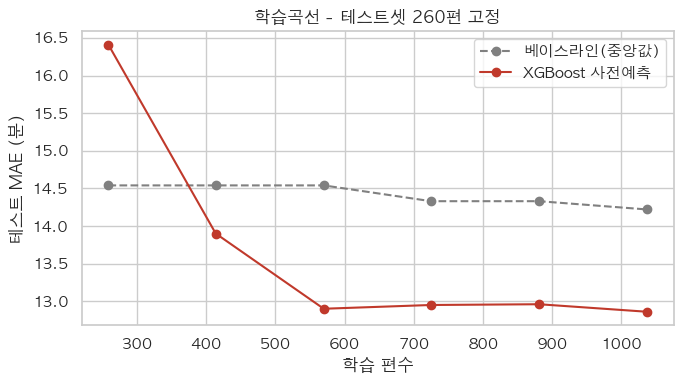

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["학습 편수"], curve["베이스라인 MAE"], "o--", color="gray", label="베이스라인(중앙값)")
ax.plot(curve["학습 편수"], curve["사전예측 MAE"], "o-", color="#c0392b", label="XGBoost 사전예측")
ax.set_xlabel("학습 편수"); ax.set_ylabel("테스트 MAE (분)")
ax.set_title(f"학습곡선 - 테스트셋 {len(test)}편 고정")
ax.legend(); plt.tight_layout(); plt.show()

**570편(약 4일치)에서 평평해진다.** 이후 467편을 더 넣어도 MAE 는
12.86~12.96 사이에서 움직이지 않고 R2 도 0.17~0.18 에 머문다.

따라서 **표본의 양은 이미 충분하다.** 같은 성격의 데이터를 더 모으는 것으로는
성능이 오르지 않는다. 남은 병목은 양이 아니라 1절에서 본 기상 변동의 부재다.

> `src/CLAUDE.md` 에 적힌 "학습곡선상 표본 부족이 원인" 이라는 진단은 527편 시점의
> 것이다. 1,297편인 지금은 더 이상 맞지 않는다.

## 3. 과거 7년, 같은 달력 창의 악기상 빈도

남은 수집 구간과 **같은 달력 창(9/16 ~ 12/12, 88일)** 으로 2019~2025 를 잘라 센다.
올해를 예측하는 것이 아니라, 이 창에서 무엇이 얼마나 나오는지를 본다.

In [5]:
def window(df):
    d = df.obs_time
    return df[((d.dt.month == 9) & (d.dt.day >= 16)) | d.dt.month.isin([10, 11])
              | ((d.dt.month == 12) & (d.dt.day <= 12))]

past = window(m[m.obs_time.dt.year < 2026])

rows = []
for y, g in past.groupby(g_year := past.obs_time.dt.year):
    rows.append({
        "연도": y, "총일수": g.date.nunique(),
        "비 온 날": g[g.wx_ra == 1].date.nunique(),
        "안개/연무": g[(g.wx_fg == 1) | (g.wx_br == 1)].date.nunique(),
        "시정<8km": g[g.visibility_km < 8].date.nunique(),
        "시정<5km": g[g.visibility_km < 5].date.nunique(),
        "돌풍>10m/s": g[g.gust_ms > 10].date.nunique(),
        "뇌우(시간)": int(g.wx_ts.sum()),
        "눈(시간)": int(g.wx_sn.sum()),
    })
yearly = pd.DataFrame(rows)
print("9/16 ~ 12/12 (단위: 일, 명시된 것만 시간)")
print(yearly.to_string(index=False))
print("\n7년 평균")
print(yearly.drop(columns=["연도"]).mean().round(1).to_string())

9/16 ~ 12/12 (단위: 일, 명시된 것만 시간)
  연도  총일수  비 온 날  안개/연무  시정<8km  시정<5km  돌풍>10m/s  뇌우(시간)  눈(시간)
2019   88     18     15      22      15         6       4      0
2020   88     12      7      15       7         6       2      0
2021   88     17      9      13       9         7       3      0
2022   88     17      3      24       3         9       0      0
2023   88     19     18      28      19        14       2      1
2024   88     22     14      22      14        14      22      0
2025   88     23     12      21      12         7       1      0

7년 평균
총일수        88.00
비 온 날      18.30
안개/연무      11.10
시정<8km     20.70
시정<5km     11.30
돌풍>10m/s    9.00
뇌우(시간)      4.90
눈(시간)       0.10


**눈은 7년 통틀어 1시간이다.** 부산에서 12월 12일 이전에 눈·결빙을 기대할 수 없다.
`wx_sn`·`wx_fz` 는 프로젝트가 끝날 때까지 상수로 남는다고 보는 것이 맞다.

그러나 나머지는 충분히 나온다. 88일 기준 7년 평균으로

- 비 온 날 **18.3일**
- 시정 8km 미만 **20.7일**, 5km 미만 **11.3일**
- 안개/연무 **11.1일**
- 돌풍 10m/s 초과 **9.0일**

연도별 편차는 크다(안개/연무 3~18일, 뇌우 0~22시간). 특정 해에 기대면 안 되지만,
어느 해든 저시정은 최소 13일 이상 있었다.

## 4. 언제 집중되나

남은 기간 안에서도 시기에 따라 다르다. 일정 계획에 직결된다.

연당 평균 일수
       기간  시정<8km    비  안개/연무
    9월 하순    5.30 5.10   3.60
      10월    6.60 7.10   3.70
      11월    6.60 4.90   3.30
12월 1~12일    2.30 1.10   0.60


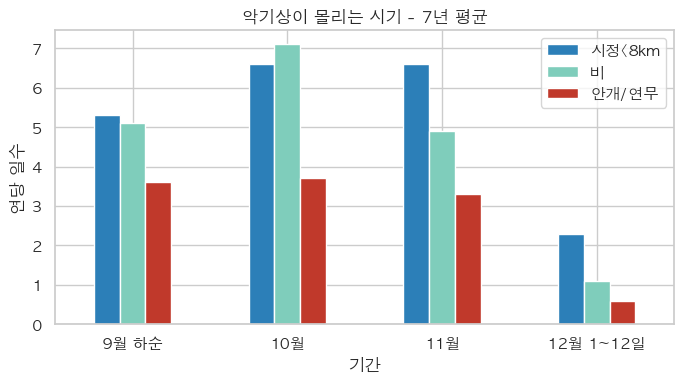

In [6]:
lab = {9: "9월 하순", 10: "10월", 11: "11월", 12: "12월 1~12일"}
rows = []
for mo in [9, 10, 11, 12]:
    g = past[past.obs_time.dt.month == mo]
    n_yr = g.obs_time.dt.year.nunique()
    rows.append({"기간": lab[mo],
                 "시정<8km": round(g[g.visibility_km < 8].date.nunique() / n_yr, 1),
                 "비": round(g[g.wx_ra == 1].date.nunique() / n_yr, 1),
                 "안개/연무": round(g[(g.wx_fg == 1) | (g.wx_br == 1)].date.nunique() / n_yr, 1)})
monthly = pd.DataFrame(rows)
print("연당 평균 일수")
print(monthly.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
monthly.set_index("기간").plot.bar(ax=ax, color=["#2c7fb8", "#7fcdbb", "#c0392b"], rot=0)
ax.set_ylabel("연당 일수"); ax.set_title("악기상이 몰리는 시기 - 7년 평균")
plt.tight_layout(); plt.show()

악기상은 **9월 하순 ~ 11월에 몰려 있고, 12월 1~12일은 거의 비어 있다**
(저시정 2.3일, 비 1.1일). 12월은 건조하고 맑은 시기다.

일정에 직접 영향이 있다. **12월에 데이터를 더 기다리는 것은 의미가 없다.**
11월 말에 표본을 확정하고 12월은 재검증·보고서에 쓰는 편이 낫다.
반대로 10~11월 수집을 거르면 그 해의 저시정 사례를 통째로 잃는다.

## 5. 저시정은 얼마나 깊어지나

시정이 낮아지는 '날'이 있다는 것과, 운항에 영향을 줄 만큼 낮아지는지는 다른 문제다.

과거 7년 같은 창 최저 시정: 0.19 km
현재 보유 9일치 최저 시정: 9.99 km

  시정 <    8 km     910시간  ( 6.2%)
  시정 <    5 km     354시간  ( 2.4%)
  시정 <    3 km      63시간  ( 0.4%)
  시정 <  1.6 km      44시간  ( 0.3%)
  시정 <  0.8 km       3시간  ( 0.0%)


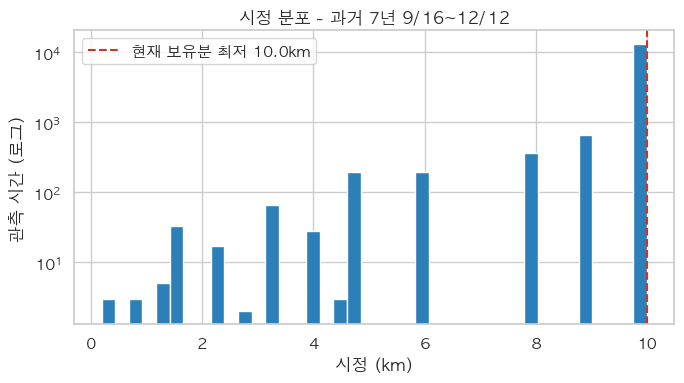

In [7]:
print(f"과거 7년 같은 창 최저 시정: {past.visibility_km.min():.2f} km")
print(f"현재 보유 9일치 최저 시정: {flights.visibility_km.min():.2f} km\n")

for th in [8, 5, 3, 1.6, 0.8]:
    n = int((past.visibility_km < th).sum())
    print(f"  시정 < {th:>4} km   {n:5,d}시간  ({(past.visibility_km < th).mean() * 100:4.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(past.visibility_km.dropna(), bins=40, color="#2c7fb8")
ax.axvline(flights.visibility_km.min(), color="#c0392b", ls="--",
           label=f"현재 보유분 최저 {flights.visibility_km.min():.1f}km")
ax.set_yscale("log"); ax.set_xlabel("시정 (km)"); ax.set_ylabel("관측 시간 (로그)")
ax.set_title("시정 분포 - 과거 7년 9/16~12/12")
ax.legend(); plt.tight_layout(); plt.show()

과거 7년 같은 창의 **최저 시정은 0.19km** 다. 현재 보유분은 최저가 9.99km 로,
저시정이 한 시간도 없다.

깊이별로는 8km 미만 6.2%, 5km 미만 2.4%, 3km 미만 0.4% 다. 운항에 실질적 제약이
걸리는 1.6km 미만도 44시간 있다. 착륙은 활주로가 보여야 하므로 시정 저하는
복행·회항으로 이어지고 지연에 직결된다 — 이 프로젝트가 잡으려는 사례가 이것이다.

## 6. 편수로 환산하면

기상은 '시간' 단위, 학습 표본은 '편' 단위다. 저시정 시간대에 몇 편이 걸리는지 환산한다.

In [8]:
days_left = (pd.Timestamp("2026-12-12") - pd.Timestamp("2026-09-16")).days
low_hours_per_yr = (past.visibility_km < 8).sum() / past.obs_time.dt.year.nunique()
rain_hours_per_yr = past.wx_ra.sum() / past.obs_time.dt.year.nunique()

# 운항 시간대(첫 편~막 편)에 편수가 고르게 분포한다고 보고 환산
op_hours = flights.hour.max() - flights.hour.min() + 1
per_op_hour = per_day / op_hours

print(f"남은 수집일 {days_left}일, 하루 평균 {per_day:.0f}편 → 예상 총 {days_left * per_day:,.0f}편\n")
print(f"  저시정(<8km)  연평균 {low_hours_per_yr:,.0f}시간 → 약 {low_hours_per_yr * per_op_hour:,.0f}편")
print(f"  강수          연평균 {rain_hours_per_yr:,.0f}시간 → 약 {rain_hours_per_yr * per_op_hour:,.0f}편")
print(f"\n현재 보유 전체 표본이 {len(flights):,}편이다.")

남은 수집일 87일, 하루 평균 144편 → 예상 총 12,538편

  저시정(<8km)  연평균 130시간 → 약 1,102편
  강수          연평균 115시간 → 약 972편

현재 보유 전체 표본이 1,297편이다.


남은 87일에 약 12,500편이 쌓이고, 그중 **저시정 시간대가 약 1,100편, 강수가 약 970편**
으로 환산된다. 현재 보유 표본 전체(1,297편)에 맞먹는 양이다.

2절에서 본 포화 지점이 570편이었으므로, 악기상 표본만으로도 학습이 성립하는 규모다.

> 운항 시간대에 편수가 고르게 분포한다고 가정한 환산이다. 실제로는 새벽에 편이 적어
> 그 시간대 저시정은 덜 잡힌다. 위 수치는 상한에 가깝게 본 값이다.

## 7. 결론

**1. 표본의 양은 이미 충분하다.** 570편에서 학습곡선이 평평해졌다(2절).
같은 성격의 데이터를 더 모아도 성능은 오르지 않는다.

**2. 부족한 것은 기상 다양성이다.** 기상 피처 11개 중 6개가 상수이고, 시정은
고유값이 1개다(1절). 지금 모델은 기상을 쓰지 않는다.

**3. 눈·결빙은 이 기간에 확보할 수 없다.** 7년 통틀어 1시간이다(3절).
이를 전제로 한 설계는 포기하고, **저시정·강수·바람**으로 주제를 좁히는 것이 맞다.

**4. 저시정·강수는 확보된다.** 88일 중 저시정 20.7일·비 18.3일이 기대되고,
편수로는 각각 약 1,100편·970편이다(3·6절).

**5. 승부처는 10~11월이다.** 12월 1~12일은 악기상이 거의 없다(4절).
이 기간 수집 누락은 그대로 표본 손실이다.

### 성능 수치를 지금 확정하지 말 것

현재 MAE 12.86분은 **맑은 날만으로 낸 값**이다. 저시정·강수가 들어오면 반드시
나빠진다. 그것이 정상이며, 보고서에는 "맑은 날 대비 악기상 포함" 대비가 결과가 된다.